# 02 - Heat Equation Experiments
**AC-PINN Project** | Authors: Suyash Vasal Jain, Nishita Raghvendra

**PDE:** $u_t = \alpha u_{xx}$, $\alpha = 0.01$

**IC:** $u(x,0) = \sin(\pi x)$ | **BC:** $u(-1,t) = u(1,t) = 0$

**Domain:** $x \in [-1,1]$, $t \in [0,1]$

**Architecture:** `[2, 32, 32, 32, 1]` | **Epochs:** 10000

**Note:** Heat equation is smooth - used as baseline to confirm AC-PINN
does not hurt performance on easy problems.

In [1]:
import sys, os
sys.path.append('..')
import torch
import numpy as np
import matplotlib.pyplot as plt
from pinn_base import (
    device, NoisyDataGenerator, PINNSolver, ACPINNSolver,
    HeatFDM, Benchmark, save_metrics, save_history, save_training_plots
)

PDE        = 'heat'
LAYERS     = [2, 32, 32, 32, 1]
EPOCHS     = 10000
PDE_PARAMS = {'alpha': 0.01}
RESULTS    = '../results/heat/'
FIGURES    = '../figures/heat/'
os.makedirs(RESULTS, exist_ok=True)
os.makedirs(FIGURES, exist_ok=True)

gen = NoisyDataGenerator(pde=PDE, alpha=0.01)
print(f'Device: {device}')

Device: cuda


## Section 1 - FDM Ground Truth

HeatFDM solved in 0.2822s

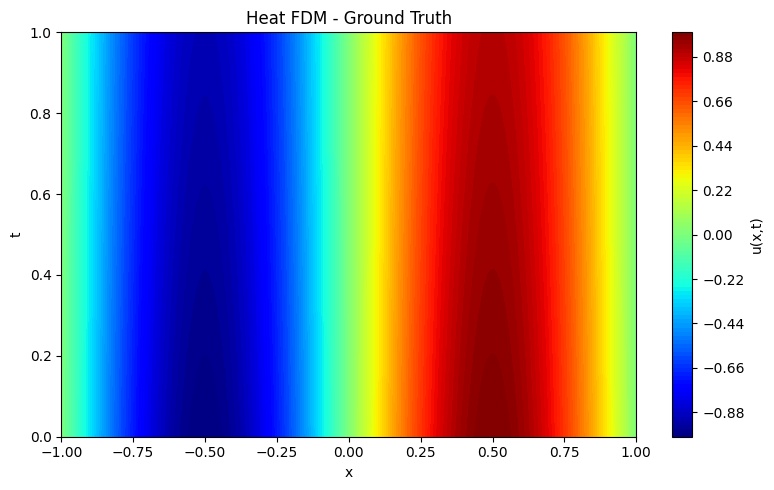

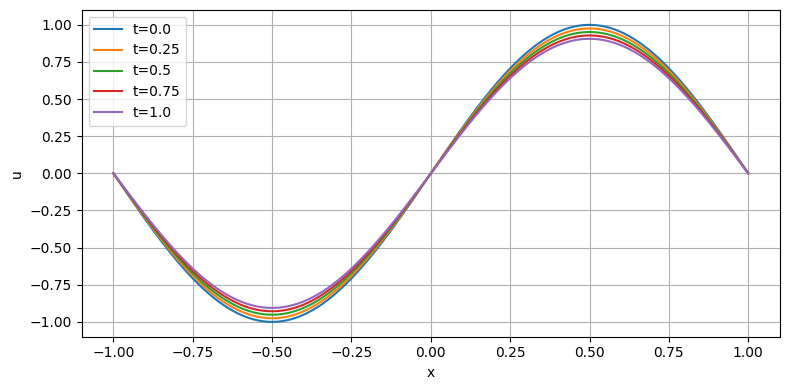

In [2]:
fdm = HeatFDM(nx=256, nt=1000, alpha=0.01)
fdm.solve()
fdm.plot_solution(title='Heat FDM - Ground Truth')
fdm.plot_time_slices()

## Section 2 - Data Conditions

In [3]:
data_clean_dense  = gen.generate(N_ic=1000, N_bc=1000, N_f=8000, noise_eps=0.0)
data_noisy_sparse = gen.generate(N_ic=20,   N_bc=20,   N_f=2000, noise_eps=0.1)
print('Data ready')

Data ready


## Section 3 - Vanilla PINN, Clean Dense

D:\PINN\ac-pinn-project\ac-pinn-project\venv\Lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


[Heat | Vanilla Clean | Epoch     0/10000] Total: 1.698939 | IC: 0.864199 | BC: 0.406124 | PDE: 0.085723


[Heat | Vanilla Clean | Epoch  1000/10000] Total: 0.000637 | IC: 0.000289 | BC: 0.000045 | PDE: 0.000061


[Heat | Vanilla Clean | Epoch  2000/10000] Total: 0.000168 | IC: 0.000038 | BC: 0.000072 | PDE: 0.000012


[Heat | Vanilla Clean | Epoch  3000/10000] Total: 0.000066 | IC: 0.000010 | BC: 0.000021 | PDE: 0.000007


...

[Heat | Vanilla Clean | Epoch  6000/10000] Total: 0.000030 | IC: 0.000005 | BC: 0.000013 | PDE: 0.000003


[Heat | Vanilla Clean | Epoch  7000/10000] Total: 0.000027 | IC: 0.000004 | BC: 0.000011 | PDE: 0.000002


[Heat | Vanilla Clean | Epoch  8000/10000] Total: 0.000024 | IC: 0.000004 | BC: 0.000010 | PDE: 0.000002


[Heat | Vanilla Clean | Epoch  9000/10000] Total: 0.000032 | IC: 0.000005 | BC: 0.000015 | PDE: 0.000002



Training complete in 93.34s


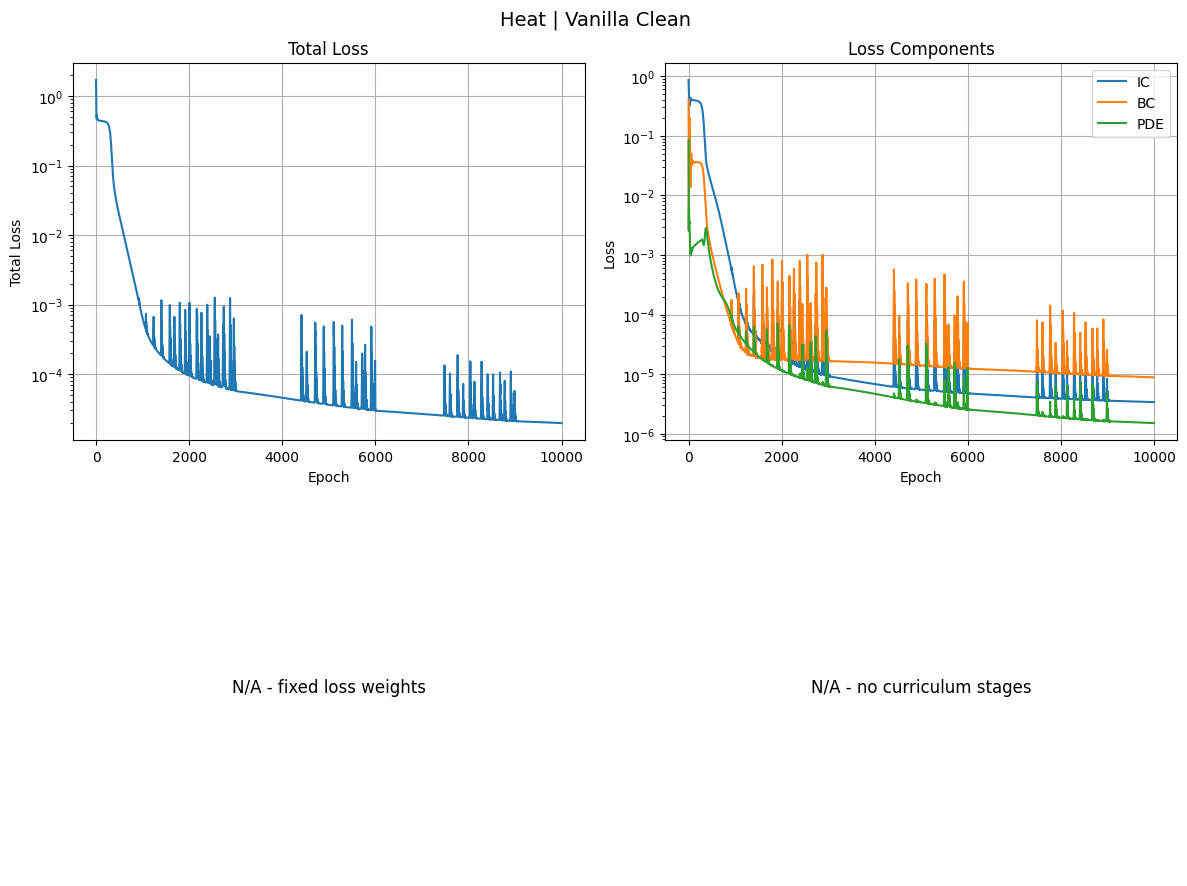

Saved: ../figures/heat/vanilla_clean_training.png
Saved: ../figures/heat/vanilla_clean_training.csv


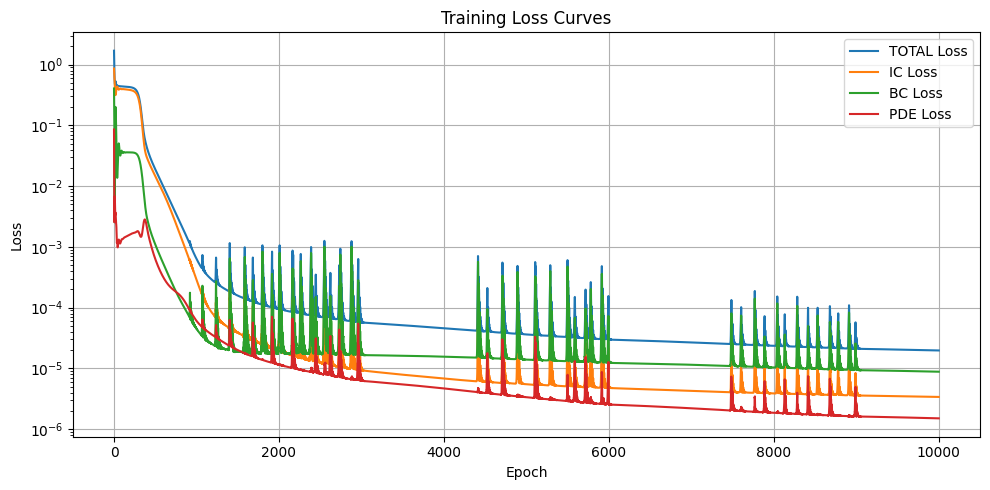

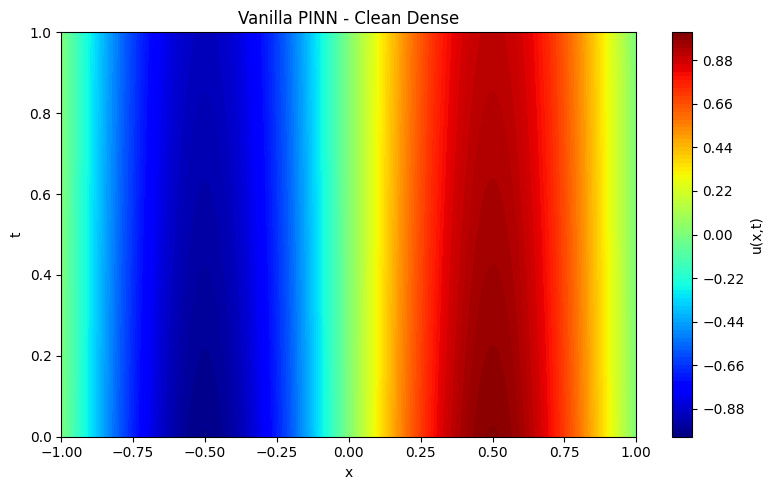

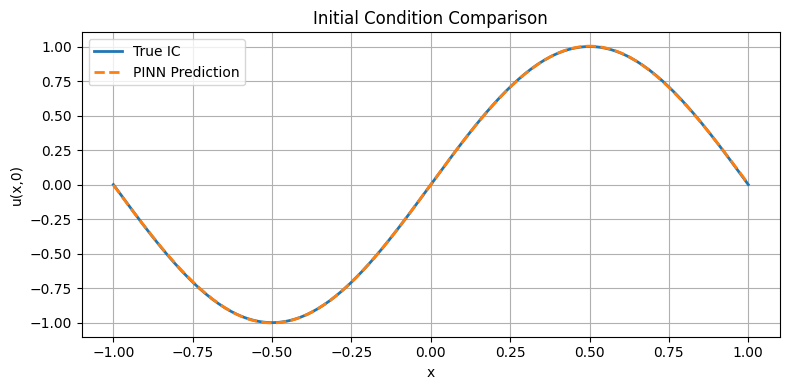

Saved: ../results/heat/vanilla_clean_history.npy


In [4]:
vanilla_clean = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vc = vanilla_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Heat | Vanilla Clean')
save_training_plots(h_vc, FIGURES+'vanilla_clean_training.png', 'Heat | Vanilla Clean')
vanilla_clean.plot_loss_history(h_vc)
vanilla_clean.plot_solution(title='Vanilla PINN - Clean Dense')
vanilla_clean.plot_initial_condition_comparison(gen)
save_history(h_vc, RESULTS+'vanilla_clean_history.npy')

## Section 4 - Vanilla PINN, Noisy Sparse

[Heat | Vanilla Noisy | Epoch     0/10000] Total: 1.107968 | IC: 0.847232 | BC: 0.230805 | PDE: 0.005986


[Heat | Vanilla Noisy | Epoch  1000/10000] Total: 0.020330 | IC: 0.007808 | BC: 0.012293 | PDE: 0.000046


[Heat | Vanilla Noisy | Epoch  2000/10000] Total: 0.019689 | IC: 0.007210 | BC: 0.012309 | PDE: 0.000034


[Heat | Vanilla Noisy | Epoch  3000/10000] Total: 0.019483 | IC: 0.007034 | BC: 0.012237 | PDE: 0.000042


[Heat | Vanilla Noisy | Epoch  4000/10000] Total: 0.019160 | IC: 0.006763 | BC: 0.012144 | PDE: 0.000051


...

[Heat | Vanilla Noisy | Epoch  6000/10000] Total: 0.018755 | IC: 0.006439 | BC: 0.011956 | PDE: 0.000072


[Heat | Vanilla Noisy | Epoch  7000/10000] Total: 0.018629 | IC: 0.006334 | BC: 0.011902 | PDE: 0.000079


[Heat | Vanilla Noisy | Epoch  8000/10000] Total: 0.018625 | IC: 0.006265 | BC: 0.011907 | PDE: 0.000091


[Heat | Vanilla Noisy | Epoch  9000/10000] Total: 0.018229 | IC: 0.005993 | BC: 0.011746 | PDE: 0.000098



Training complete in 89.16s


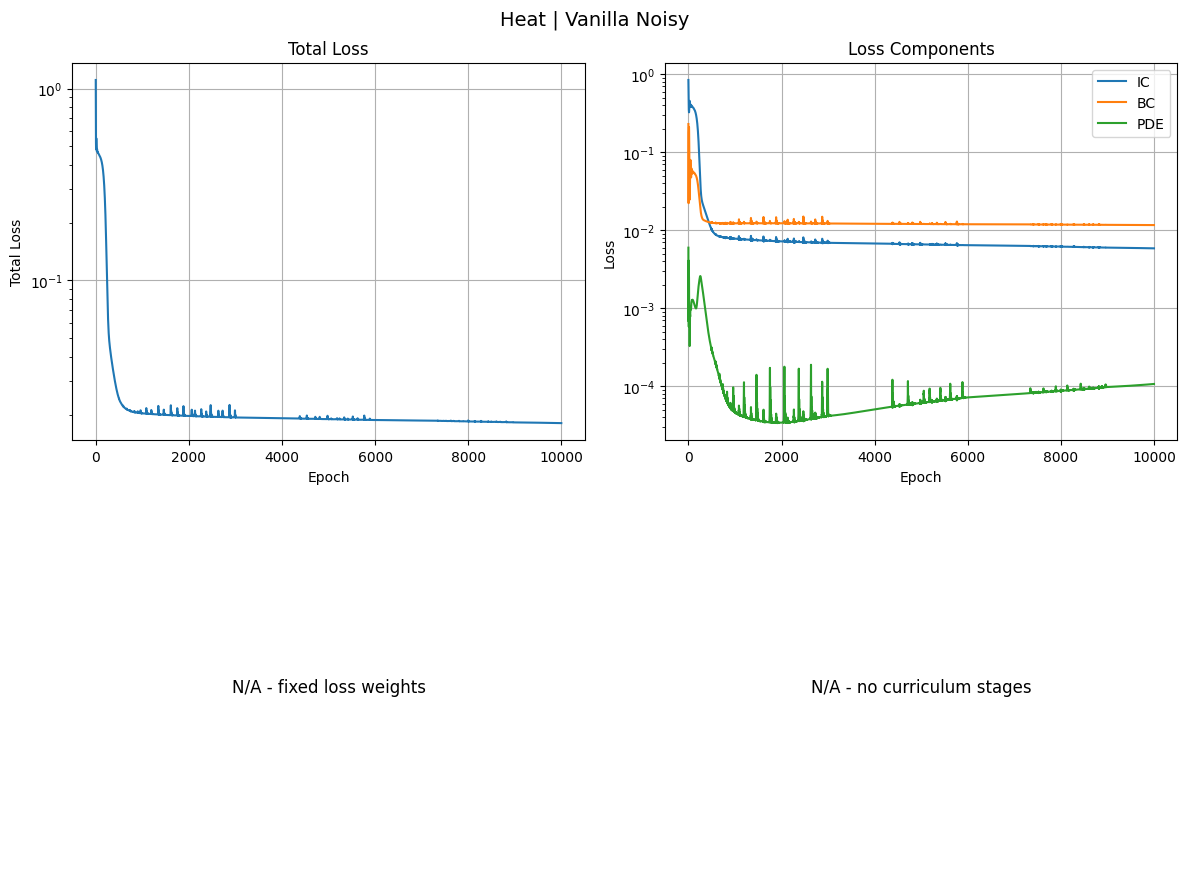

Saved: ../figures/heat/vanilla_noisy_training.png
Saved: ../figures/heat/vanilla_noisy_training.csv


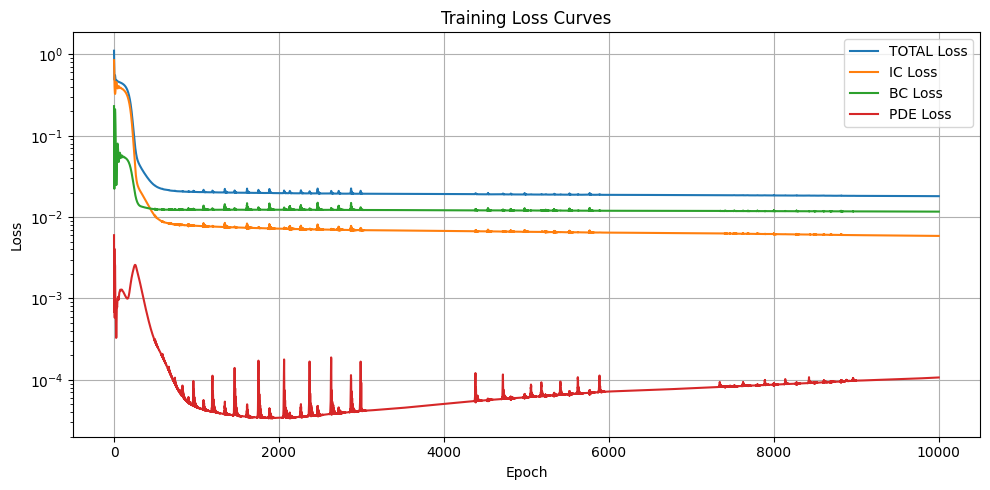

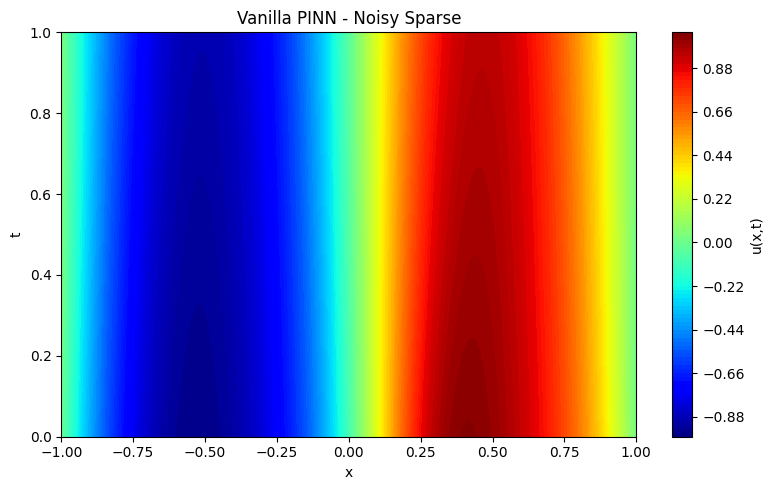

Saved: ../results/heat/vanilla_noisy_history.npy


In [5]:
vanilla_noisy = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
h_vn = vanilla_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Heat | Vanilla Noisy')
save_training_plots(h_vn, FIGURES+'vanilla_noisy_training.png', 'Heat | Vanilla Noisy')
vanilla_noisy.plot_loss_history(h_vn)
vanilla_noisy.plot_solution(title='Vanilla PINN - Noisy Sparse')
save_history(h_vn, RESULTS+'vanilla_noisy_history.npy')

## Section 5 - AC-PINN, Clean Dense

[Heat | AC-PINN Clean | Epoch     0/10000] Stage 1/4 | Total: 1.956184 | IC: 1.111168 | BC: 0.843122 | PDE: 0.000379 | lam=(1.00,1.00,5.00)


[Heat | AC-PINN Clean | Epoch  1000/10000] Stage 1/4 | Total: 0.000634 | IC: 0.000111 | BC: 0.000046 | PDE: 0.000027 | lam=(2.55,1.76,10.00)


[Heat | AC-PINN Clean | Epoch  2000/10000] Stage 2/4 | Total: 0.000145 | IC: 0.000012 | BC: 0.000015 | PDE: 0.000006 | lam=(5.93,1.23,10.00)


[Heat | AC-PINN Clean | Epoch  3000/10000] Stage 3/4 | Total: 0.000021 | IC: 0.000006 | BC: 0.000008 | PDE: 0.000007 | lam=(0.85,1.16,0.99)


[Heat | AC-PINN Clean | Epoch  4000/10000] Stage 3/4 | Total: 0.000017 | IC: 0.000005 | BC: 0.000006 | PDE: 0.000006 | lam=(0.83,1.12,1.05)


...

[Heat | AC-PINN Clean | Epoch  6000/10000] Stage 3/4 | Total: 0.000010 | IC: 0.000003 | BC: 0.000003 | PDE: 0.000004 | lam=(0.82,0.98,1.20)


[Heat | AC-PINN Clean | Epoch  7000/10000] Stage 3/4 | Total: 0.000009 | IC: 0.000002 | BC: 0.000002 | PDE: 0.000004 | lam=(0.81,0.90,1.28)


[Heat | AC-PINN Clean | Epoch  8000/10000] Stage 4/4 | Total: 0.000041 | IC: 0.000004 | BC: 0.000008 | PDE: 0.000018 | lam=(0.38,0.76,1.85)


[Heat | AC-PINN Clean | Epoch  9000/10000] Stage 4/4 | Total: 0.000022 | IC: 0.000004 | BC: 0.000006 | PDE: 0.000010 | lam=(0.57,0.98,1.45)



AC-PINN training complete in 105.86s


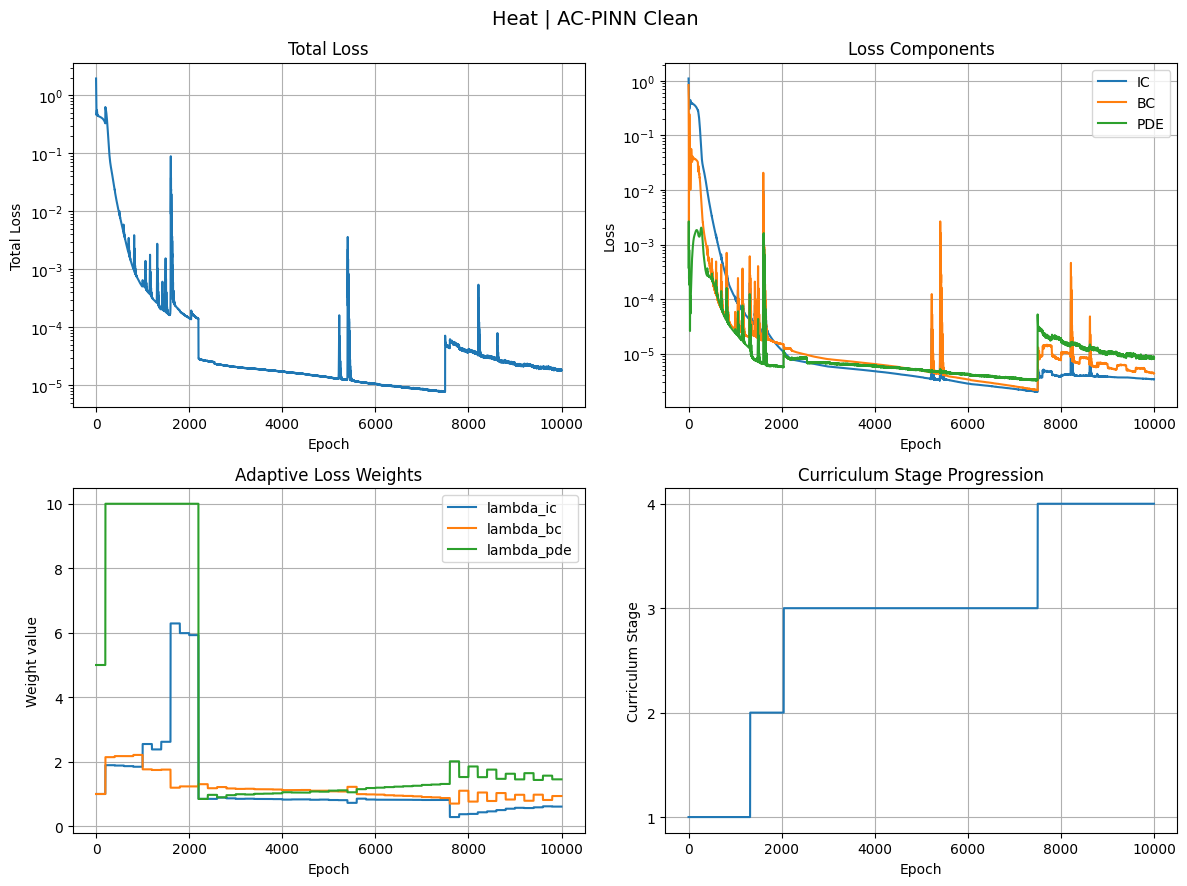

Saved: ../figures/heat/acpinn_clean_training.png
Saved: ../figures/heat/acpinn_clean_training.csv


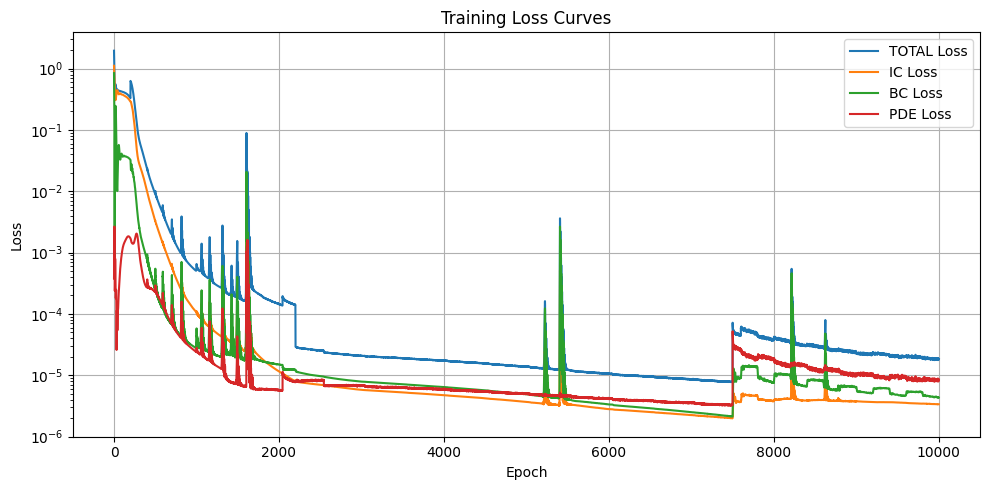

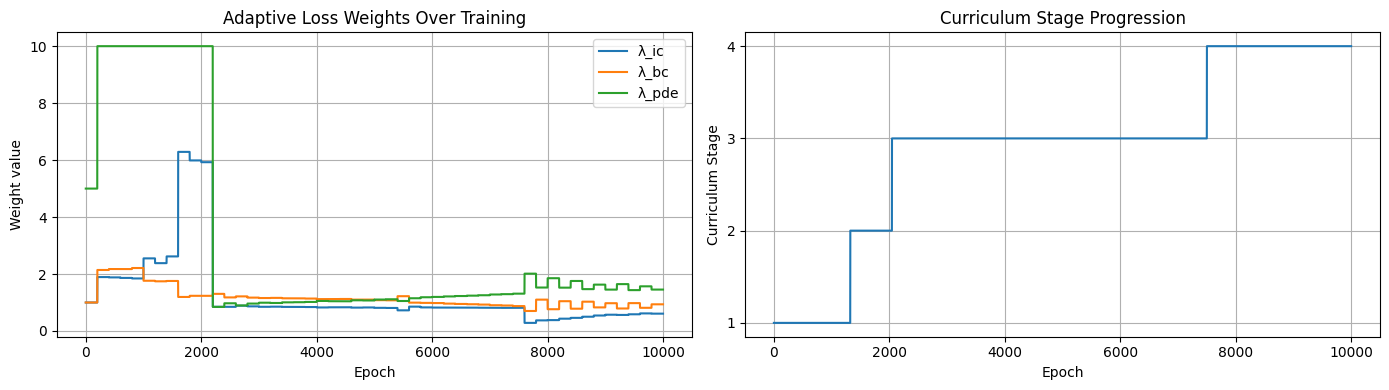

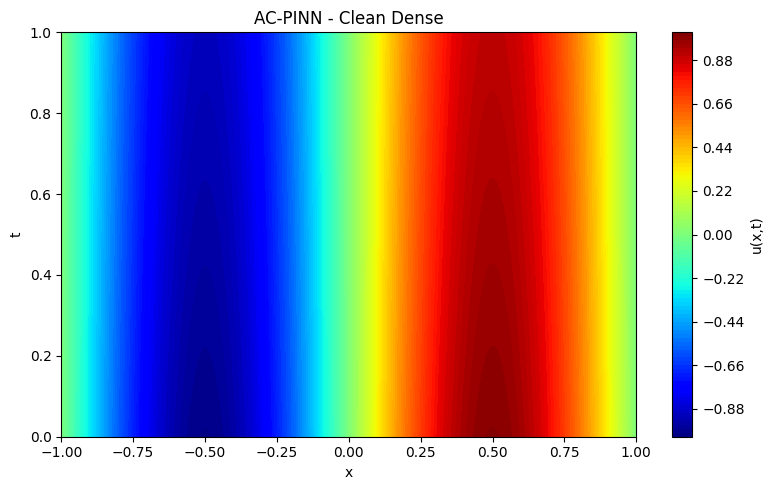

Saved: ../results/heat/ac_clean_history.npy


In [6]:
ac_clean = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_ac = ac_clean.fit(data_clean_dense, epochs=EPOCHS, print_every=1000, label='Heat | AC-PINN Clean')
save_training_plots(h_ac, FIGURES+'acpinn_clean_training.png', 'Heat | AC-PINN Clean')
ac_clean.plot_loss_history(h_ac)
ac_clean.plot_weight_history(h_ac)
ac_clean.plot_solution(title='AC-PINN - Clean Dense')
save_history(h_ac, RESULTS+'ac_clean_history.npy')

## Section 6 - AC-PINN, Noisy Sparse

[Heat | AC-PINN Noisy | Epoch     0/10000] Stage 1/4 | Total: 1.203929 | IC: 0.902364 | BC: 0.300461 | PDE: 0.000221 | lam=(1.00,1.00,5.00)


[Heat | AC-PINN Noisy | Epoch  1000/10000] Stage 2/4 | Total: 0.050047 | IC: 0.007402 | BC: 0.011788 | PDE: 0.000039 | lam=(1.50,3.27,10.00)


[Heat | AC-PINN Noisy | Epoch  2000/10000] Stage 2/4 | Total: 0.048617 | IC: 0.007297 | BC: 0.011347 | PDE: 0.000074 | lam=(1.45,3.29,10.00)


[Heat | AC-PINN Noisy | Epoch  3000/10000] Stage 2/4 | Total: 0.047082 | IC: 0.006958 | BC: 0.010826 | PDE: 0.000115 | lam=(2.18,2.89,5.09)


[Heat | AC-PINN Noisy | Epoch  4000/10000] Stage 2/4 | Total: 0.047896 | IC: 0.006818 | BC: 0.010036 | PDE: 0.000065 | lam=(1.71,3.56,7.38)


...

[Heat | AC-PINN Noisy | Epoch  6000/10000] Stage 3/4 | Total: 0.021300 | IC: 0.006494 | BC: 0.008552 | PDE: 0.001522 | lam=(1.18,1.55,0.28)


[Heat | AC-PINN Noisy | Epoch  7000/10000] Stage 3/4 | Total: 0.019844 | IC: 0.006375 | BC: 0.007980 | PDE: 0.002052 | lam=(1.17,1.46,0.38)


[Heat | AC-PINN Noisy | Epoch  8000/10000] Stage 4/4 | Total: 0.020753 | IC: 0.006271 | BC: 0.008673 | PDE: 0.004350 | lam=(0.98,1.35,0.68)


[Heat | AC-PINN Noisy | Epoch  9000/10000] Stage 4/4 | Total: 0.020690 | IC: 0.006147 | BC: 0.008750 | PDE: 0.002916 | lam=(1.04,1.47,0.49)



AC-PINN training complete in 102.59s


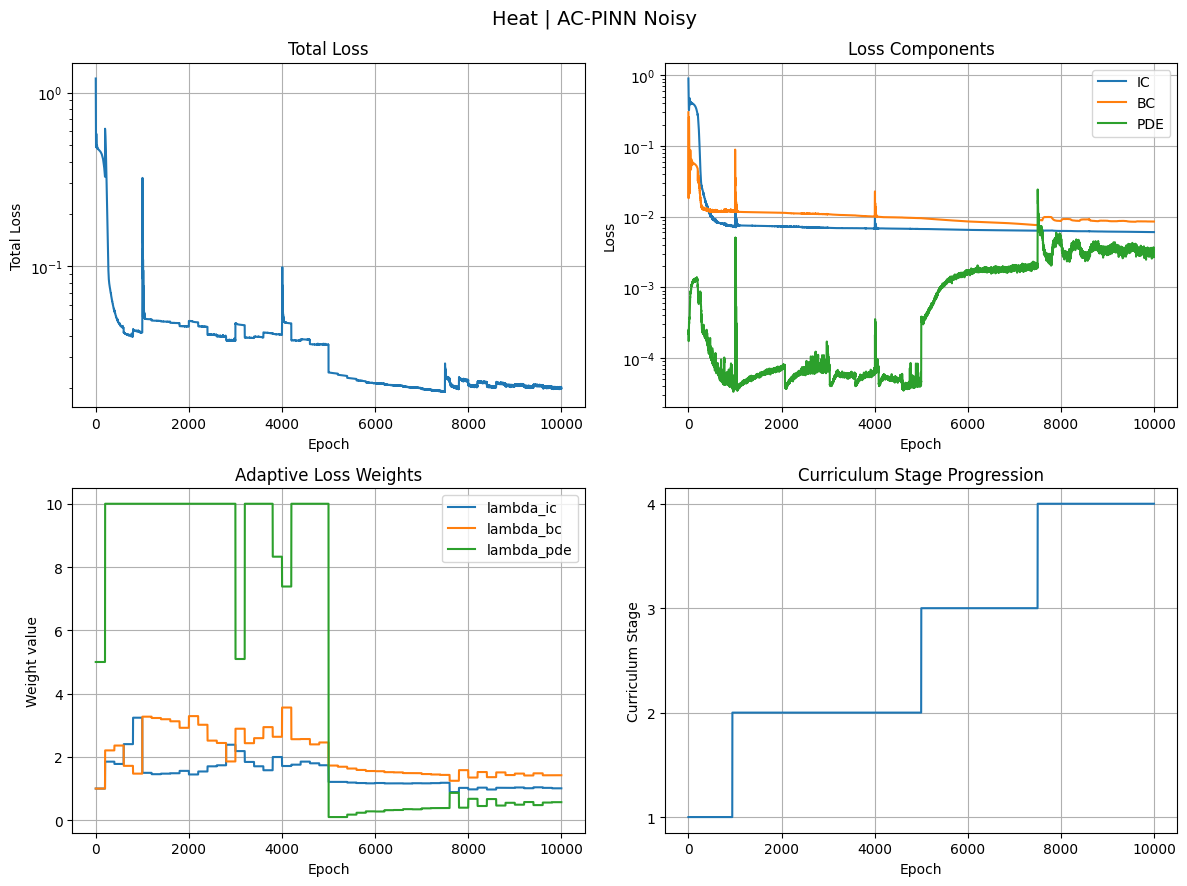

Saved: ../figures/heat/acpinn_noisy_training.png
Saved: ../figures/heat/acpinn_noisy_training.csv


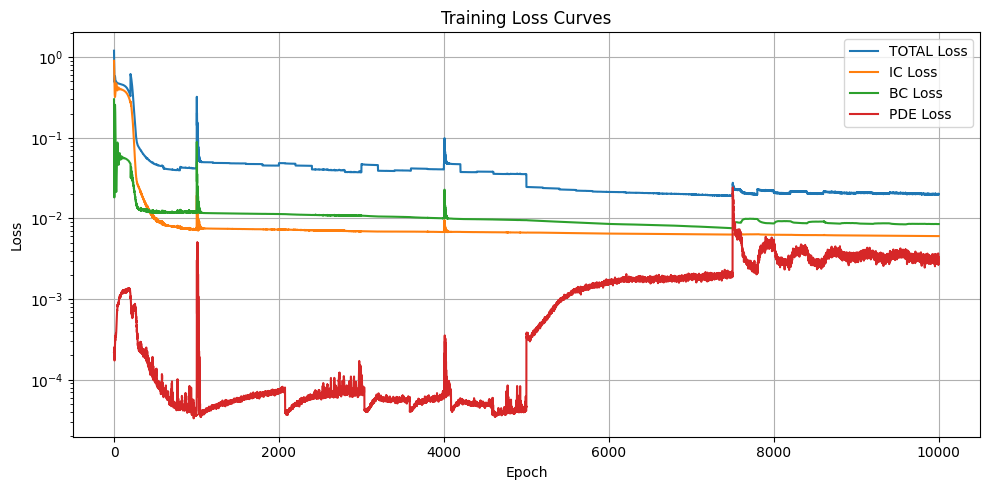

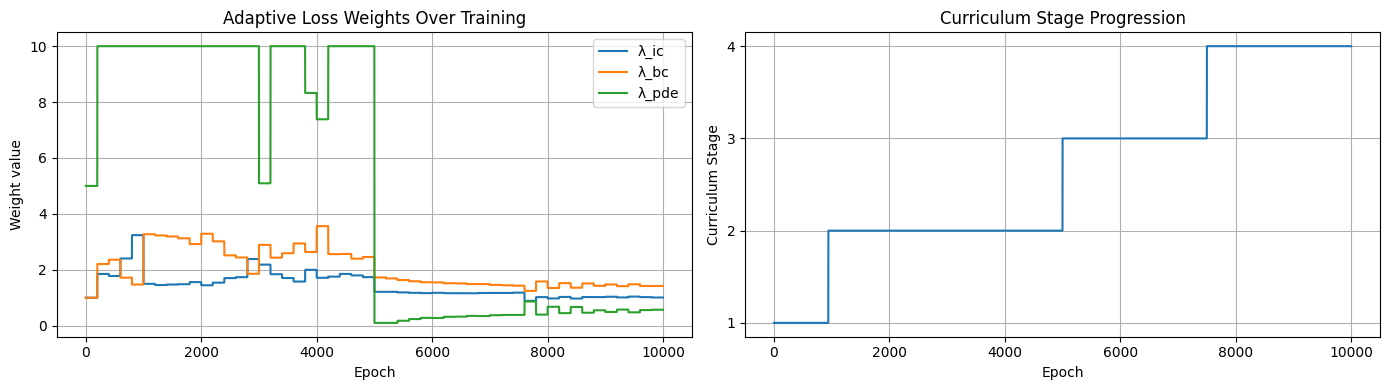

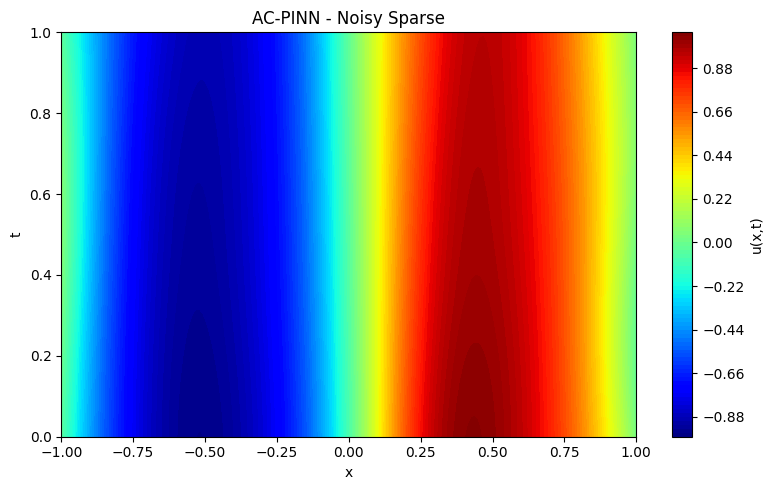

Saved: ../results/heat/ac_noisy_history.npy


In [7]:
ac_noisy = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
h_an = ac_noisy.fit(data_noisy_sparse, epochs=EPOCHS, print_every=1000, label='Heat | AC-PINN Noisy')
save_training_plots(h_an, FIGURES+'acpinn_noisy_training.png', 'Heat | AC-PINN Noisy')
ac_noisy.plot_loss_history(h_an)
ac_noisy.plot_weight_history(h_an)
ac_noisy.plot_solution(title='AC-PINN - Noisy Sparse')
save_history(h_an, RESULTS+'ac_noisy_history.npy')

## Section 7 - Benchmark vs FDM

  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla (clean)             0.001672   0.004696   0.000860   0.001124
  Vanilla (noisy)             0.078729   0.153368   0.041209   0.052923
  AC-PINN (clean)             0.001653   0.003671   0.000852   0.001111
  AC-PINN (noisy)             0.077962   0.138289   0.041675   0.052407


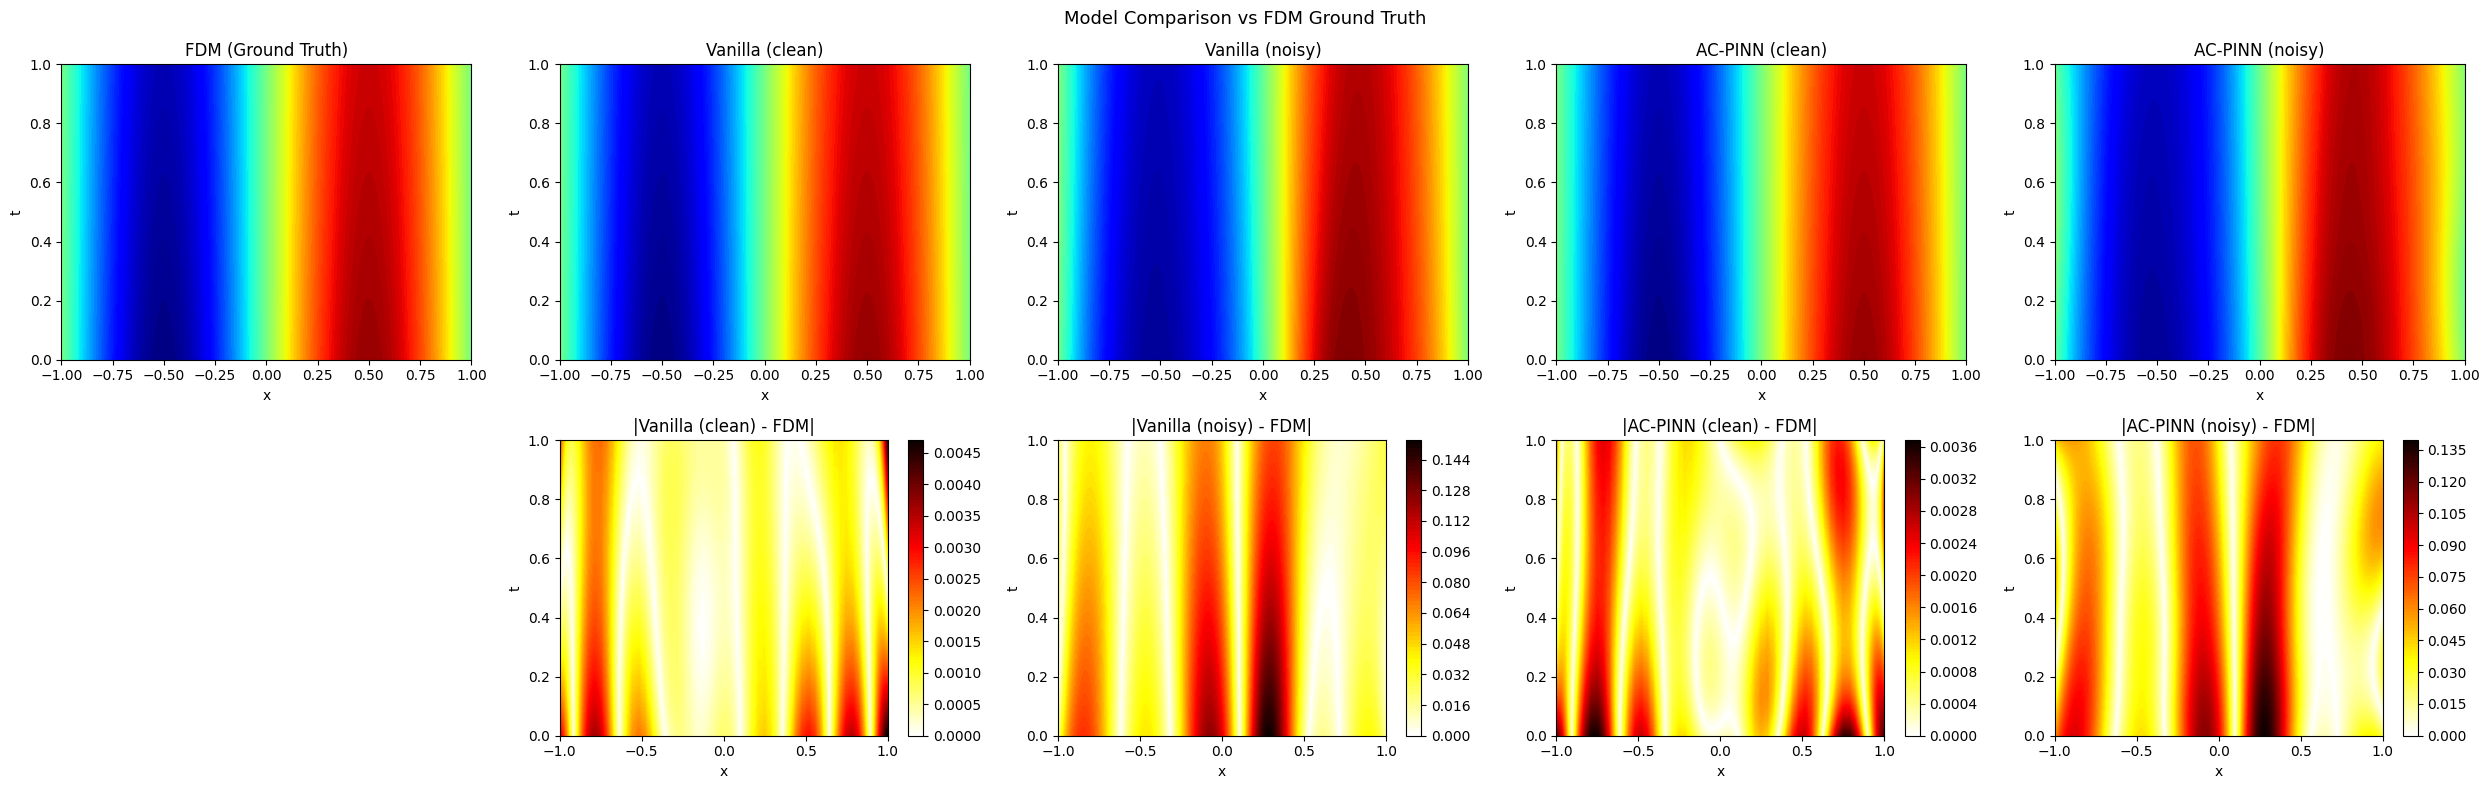

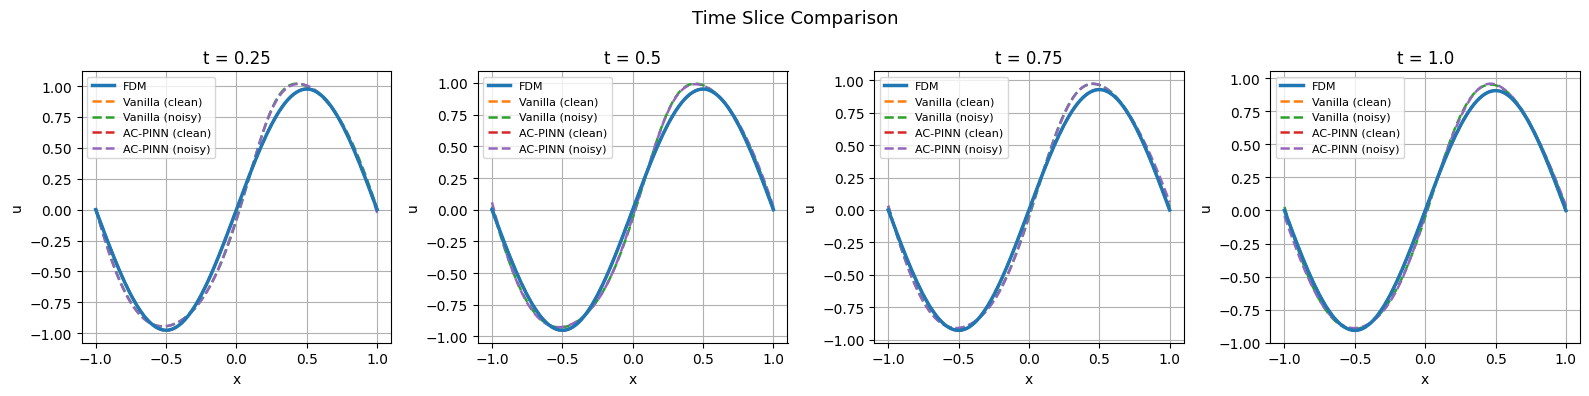

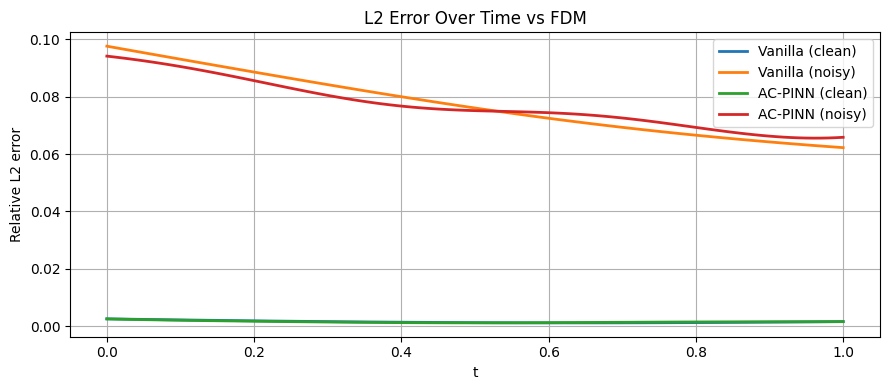

Saved: ../results/heat/benchmark_metrics.npy
Heat experiments complete.


In [8]:
bench = Benchmark(fdm, nx=200, nt=100)
bench.add('Vanilla (clean)', vanilla_clean)
bench.add('Vanilla (noisy)', vanilla_noisy)
bench.add('AC-PINN (clean)', ac_clean)
bench.add('AC-PINN (noisy)', ac_noisy)
bench.run()

metrics = bench.compare_metrics()
bench.plot_comparison(save_path=FIGURES+'comparison.png')
bench.plot_time_slices(save_path=FIGURES+'time_slices.png')
bench.plot_error_over_time(save_path=FIGURES+'error_over_time.png')

save_metrics(metrics, RESULTS+'benchmark_metrics.npy')
print('Heat experiments complete.')

## Section 8 - Noise Level Study

In [9]:
noise_results = {}
for eps in [0.05, 0.1, 0.2]:
    print(f'\n--- ε={eps} ---')
    d = gen.generate(N_ic=50, N_bc=50, N_f=3000, noise_eps=eps)
    v = PINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS)
    v.fit(d, epochs=5000, print_every=2500)
    a = ACPINNSolver(pde=PDE, layers=LAYERS, pde_params=PDE_PARAMS, weight_strategy='both')
    a.fit(d, epochs=5000, print_every=2500)
    b = Benchmark(fdm).add(f'Vanilla ε={eps}', v).add(f'AC-PINN ε={eps}', a)
    b.run()
    noise_results[eps] = b.compare_metrics()
save_metrics(noise_results, RESULTS+'noise_study_metrics.npy')


--- ε=0.05 ---
[Epoch     0/5000] Total: 0.809145 | IC: 0.549218 | BC: 0.039308 | PDE: 0.044124


[Epoch  2500/5000] Total: 0.005325 | IC: 0.001844 | BC: 0.003381 | PDE: 0.000020



Training complete in 45.38s
[Epoch     0/5000] Stage 1/4 | Total: 0.617899 | IC: 0.609582 | BC: 0.008137 | PDE: 0.000036 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.013478 | IC: 0.001713 | BC: 0.003145 | PDE: 0.000156 | lam=(4.37,1.41,10.00)



AC-PINN training complete in 52.13s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.05              0.020033   0.038948   0.011864   0.013466
  AC-PINN ε=0.05              0.022727   0.067144   0.012860   0.015278

--- ε=0.1 ---
[Epoch     0/5000] Total: 0.543445 | IC: 0.438367 | BC: 0.053781 | PDE: 0.010260


...


AC-PINN training complete in 52.29s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.1               0.031306   0.052637   0.014970   0.021044
  AC-PINN ε=0.1               0.038904   0.062276   0.022670   0.026152

--- ε=0.2 ---
[Epoch     0/5000] Total: 1.260759 | IC: 0.411355 | BC: 0.272574 | PDE: 0.115366


[Epoch  2500/5000] Total: 0.110646 | IC: 0.036422 | BC: 0.073292 | PDE: 0.000186



Training complete in 45.36s
[Epoch     0/5000] Stage 1/4 | Total: 0.915700 | IC: 0.657995 | BC: 0.125380 | PDE: 0.026465 | lam=(1.00,1.00,5.00)


[Epoch  2500/5000] Stage 3/4 | Total: 0.159804 | IC: 0.036604 | BC: 0.069098 | PDE: 0.010561 | lam=(0.94,1.77,0.29)



AC-PINN training complete in 52.19s
  Model                         Rel L2    Max Err        MAE       RMSE
  Vanilla ε=0.2               0.125872   0.259463   0.059022   0.084614
  AC-PINN ε=0.2               0.133642   0.246362   0.066541   0.089837
Saved: ../results/heat/noise_study_metrics.npy
